# Bitcoin Time Series EDA (Research-Grade Notebook)

**Muc tieu:** Thuc hien EDA toan dien cho du lieu BTC OHLCV, tap trung vao xu huong, bien dong, tinh mua vu, tuong quan va cac che do thi truong.

**Luu y:** Notebook nay phu hop cho Google Colab hoac Jupyter Notebook.

## 1. Import Libraries
Khoi tao cac thu vien can thiet va cai dat style cho visualization.

In [123]:
# Core data stack
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

# Time series & stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# ML
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "axes.titlesize": 14, "axes.labelsize": 12})

In [124]:
# Ensure Plotly renderer dependencies are available
try:
    import nbformat  # noqa: F401
except Exception:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nbformat", "ipython"])

import plotly.io as pio
pio.renderers.default = "notebook_connected"

## 2. Load Dataset
Doc file CSV, kiem tra thong tin tong quan, missing values va duplicated rows.

In [125]:
# Update path if needed
data_path = "/content/btc_ohlcv_1h.csv"  # Colab default

try:
    df = pd.read_csv(data_path)
except FileNotFoundError:
    # Fallback for local Jupyter
    df = pd.read_csv("D:\\DataMining\\sgu-2026-datamining-timeseries\\Data\\btc_ohlcv_1h.csv")

df.head()

,Date,open,high,low,close,volume
0,2024-10-01 00:00:00,63327.60,63606.00,63006.70,63531.99,1336.93335
1,2024-10-01 01:00:00,63532.00,63639.86,63370.01,63458.00,1004.08763
2,2024-10-01 02:00:00,63458.00,63458.00,63180.00,63443.76,716.11822
3,2024-10-01 03:00:00,63443.76,63744.00,63430.00,63723.48,822.21265
4,2024-10-01 04:00:00,63723.47,63879.81,63652.06,63868.94,778.75286


In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13263 entries, 0 to 13262
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    13263 non-null  str    
 1   open    13263 non-null  float64
 2   high    13263 non-null  float64
 3   low     13263 non-null  float64
 4   close   13263 non-null  float64
 5   volume  13263 non-null  float64
dtypes: float64(5), str(1)
memory usage: 867.9 KB


In [127]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,13263,13263,2024-10-01 00:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
open,13263.0,NaN,NaN,NaN,94179.411644,16129.320092,59502.0,84351.925,95456.92,107208.295,126011.18
high,13263.0,NaN,NaN,NaN,94480.728211,16132.07822,59611.01,84610.825,95762.67,107467.035,126199.63
low,13263.0,NaN,NaN,NaN,93869.241303,16121.72962,58946.0,84110.42,95192.35,106929.015,125252.74
close,13263.0,NaN,NaN,NaN,94179.889165,16128.503657,59502.01,84351.925,95456.93,107208.29,126011.18
volume,13263.0,NaN,NaN,NaN,976.242734,1087.822062,46.43346,386.62787,656.61339,1137.940105,22932.63034


In [128]:
# Missing values
df.isna().sum()

Date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [129]:
# Duplicated rows
df.duplicated().sum()

np.int64(0)

## 3. Data Preprocessing
- Chuyen `Date` sang datetime
- Sap xep theo thoi gian
- Dat `Date` lam index
- Xu ly missing values (neu co)

In [130]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.sort_values("Date").set_index("Date")

# Basic missing value handling
if df.isna().sum().sum() > 0:
    df = df.interpolate(method="time").ffill().bfill()

df.head()

,open,high,low,close,volume
Date,,,,,
2024-10-01 00:00:00,63327.60,63606.00,63006.70,63531.99,1336.93335
2024-10-01 01:00:00,63532.00,63639.86,63370.01,63458.00,1004.08763
2024-10-01 02:00:00,63458.00,63458.00,63180.00,63443.76,716.11822
2024-10-01 03:00:00,63443.76,63744.00,63430.00,63723.48,822.21265
2024-10-01 04:00:00,63723.47,63879.81,63652.06,63868.94,778.75286


## 4. Basic Time Series Visualization
Kiem tra xu huong gia, mo ta so bo ve thi truong.

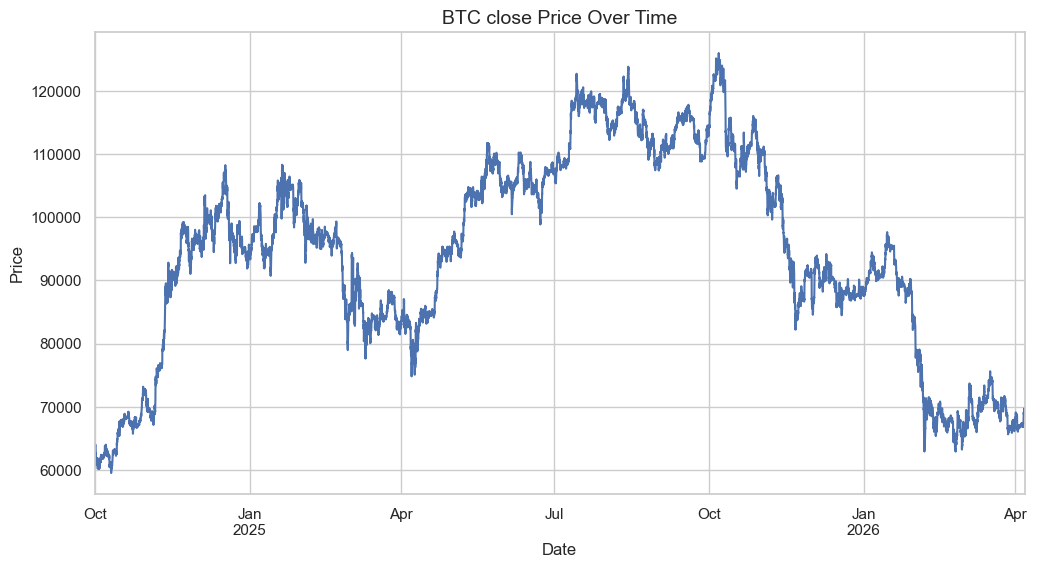

In [131]:
# close price
df["close"].plot(title="BTC close Price Over Time")
plt.ylabel("Price")
plt.show()

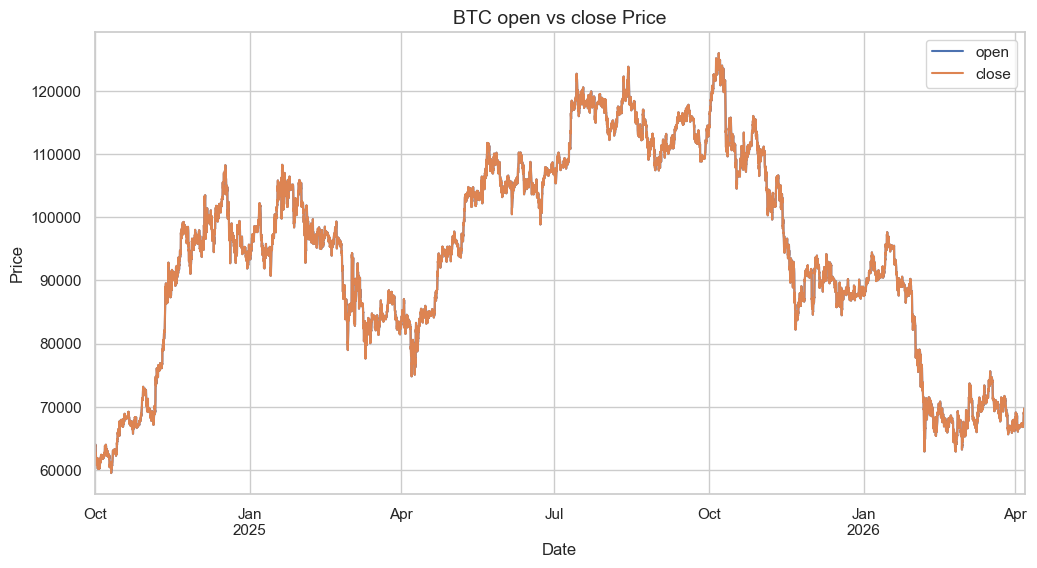

In [132]:
# open vs close
df[["open", "close"]].plot(title="BTC open vs close Price")
plt.ylabel("Price")
plt.show()

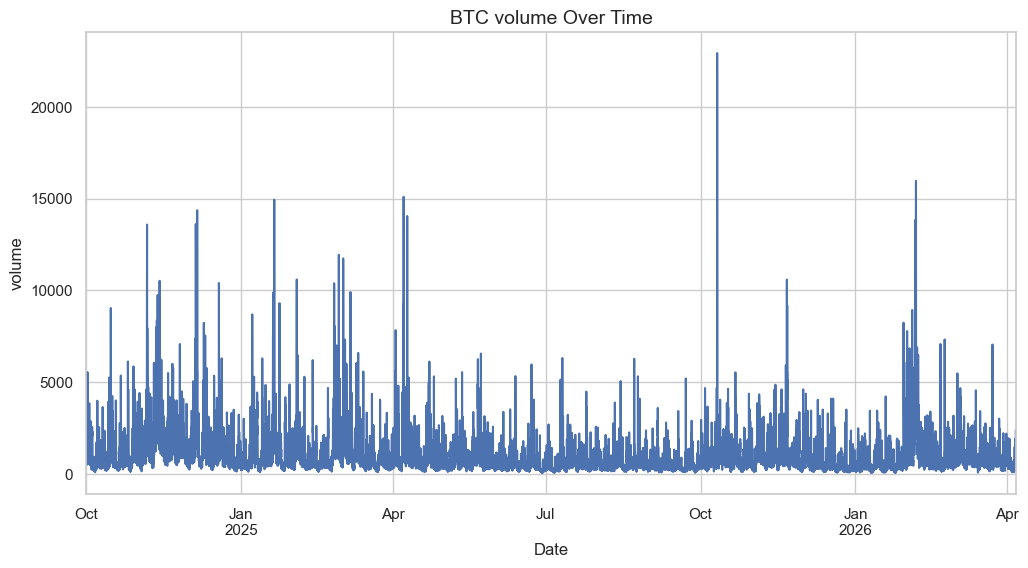

In [133]:
# volume
df["volume"].plot(title="BTC volume Over Time")
plt.ylabel("volume")
plt.show()

**Nhan xet:** Quan sat xu huong gia va volume de nhan dien cac giai doan bien dong lon (bull/bear) va nhung dot tang truong dot bien.

## 5. Candlestick Chart
Su dung Plotly de ve bieu do nen va nhan dien cac giai doan bull/bear.

In [149]:
fig = go.Figure(data=[go.Candlestick(
    x=df.index,
    open=df["open"],
    high=df["high"],
    low=df["low"],
    close=df["close"]
)])
fig.update_layout(title="BTC Candlestick Chart", xaxis_title="Date", yaxis_title="Price")
fig.show(renderer="browser")

**Nhan xet:** Quan sat cac dot tang manh lien tuc (bull) va cac pha giam sau (bear), ket hop voi volume de xac nhan dong tien.

## 6. Return Analysis
Tinh `Daily Return` va `Log Return`, phan tich phan phoi va volatility.

In [135]:
# Returns
df["Return"] = df["close"].pct_change()
df["LogReturn"] = np.log(df["close"] / df["close"].shift(1))
df[["Return", "LogReturn"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Return,13262.0,0.000019,0.004982,-0.048956,-0.002061,0.000033,0.002180,0.050270
LogReturn,13262.0,0.000007,0.004984,-0.050195,-0.002063,0.000033,0.002178,0.049047


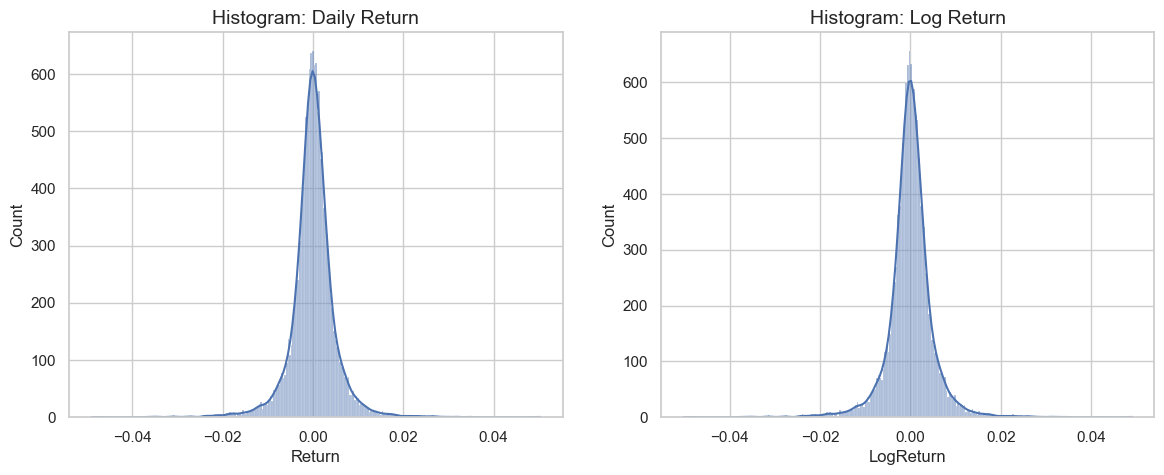

In [136]:
# Histogram + KDE
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["Return"].dropna(), kde=True, ax=ax[0])
ax[0].set_title("Histogram: Daily Return")
sns.histplot(df["LogReturn"].dropna(), kde=True, ax=ax[1])
ax[1].set_title("Histogram: Log Return")
plt.show()

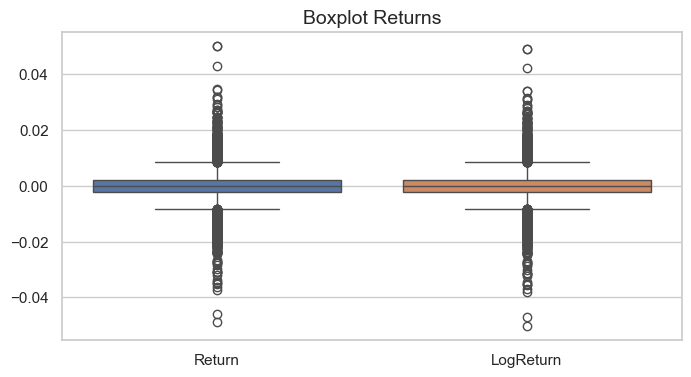

In [137]:
# Boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(data=df[["Return", "LogReturn"]])
plt.title("Boxplot Returns")
plt.show()

**Phan tich:** Return thuong co phan phoi lech (skew) va day day (fat-tail), the hien rui ro extreme move va volatility cao.

## 7. Rolling Statistics (Moving Average)
Tinh MA7, MA30, MA90 va quan sat xu huong.

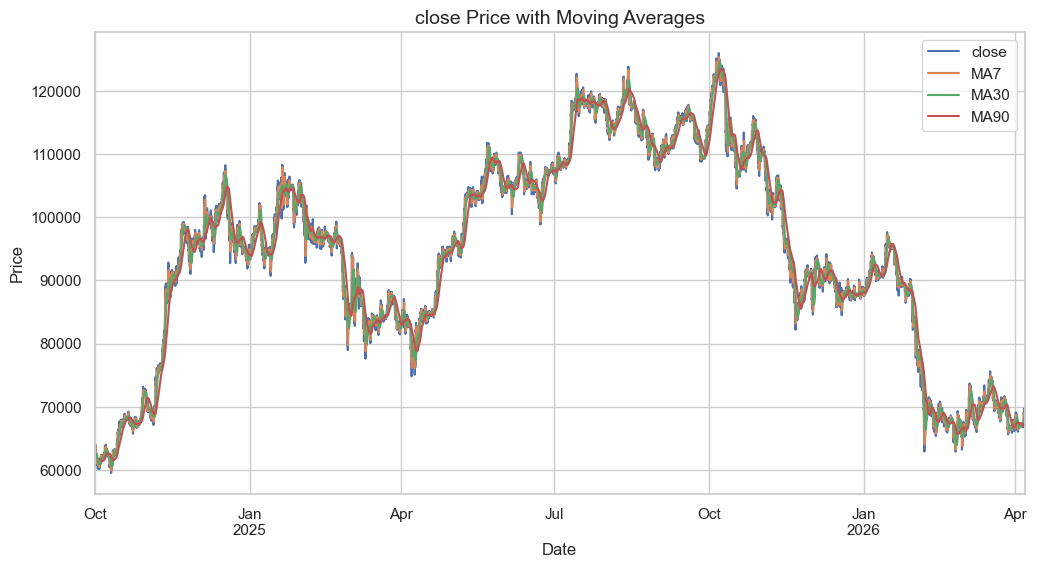

In [138]:
df["MA7"] = df["close"].rolling(window=7).mean()
df["MA30"] = df["close"].rolling(window=30).mean()
df["MA90"] = df["close"].rolling(window=90).mean()

df[["close", "MA7", "MA30", "MA90"]].plot(title="close Price with Moving Averages")
plt.ylabel("Price")
plt.show()

**Phan tich:** MA giup lam muot xu huong; crossover (MA7 vs MA30) co the bao hieu bien dong ngan han va trung han.

## 8. Volatility Analysis
Tinh rolling volatility 7 ngay va 30 ngay tu log return.

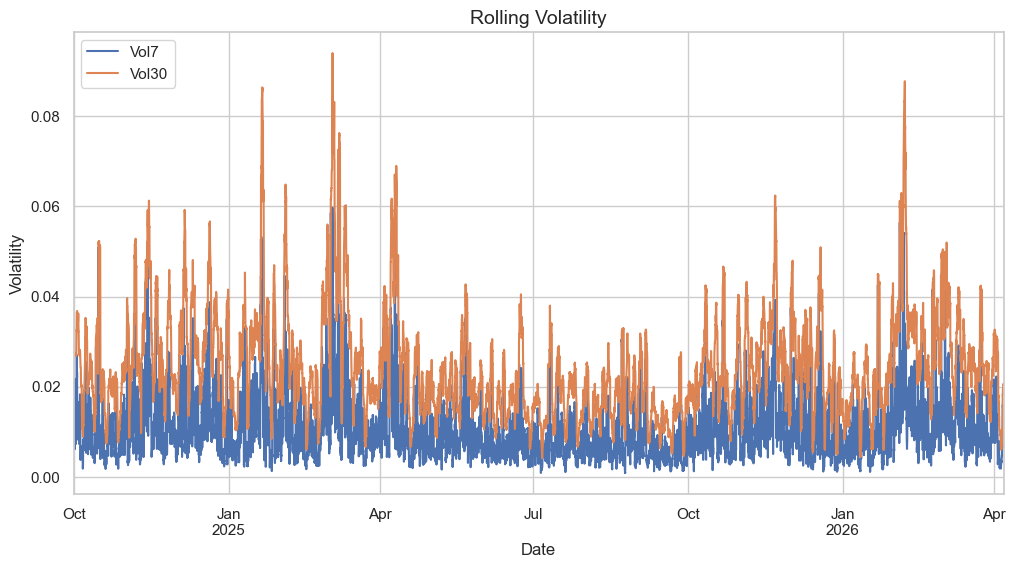

In [139]:
df["Vol7"] = df["LogReturn"].rolling(window=7).std() * np.sqrt(7)
df["Vol30"] = df["LogReturn"].rolling(window=30).std() * np.sqrt(30)

df[["Vol7", "Vol30"]].plot(title="Rolling Volatility")
plt.ylabel("Volatility")
plt.show()

**Phan tich:** Cac dot volatility cao thuong trung voi panic/crash, phan anh risk tang dot bien.

## 9. volume Analysis
Phan tich spike volume va moi quan he volume - price.

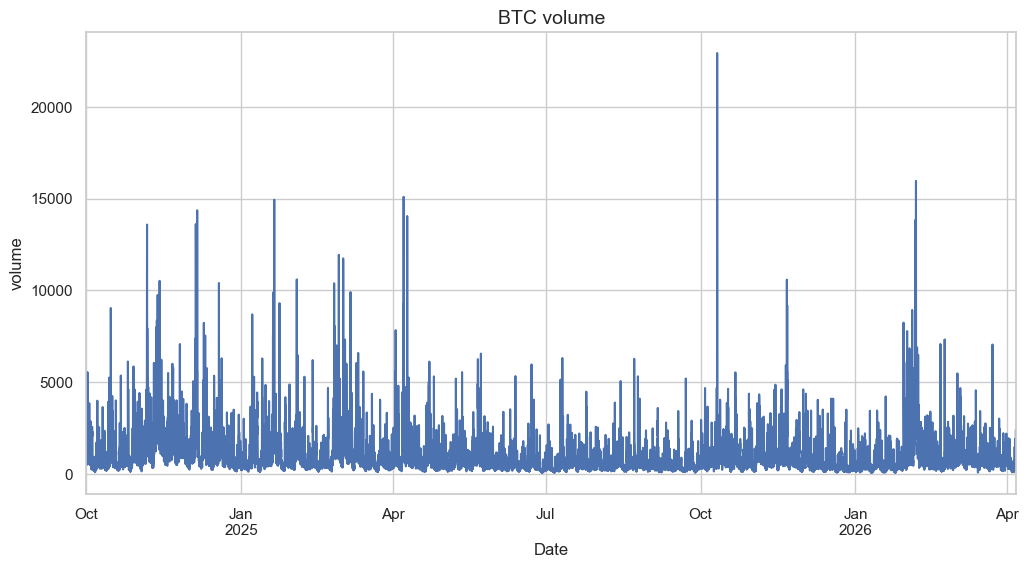

In [140]:
df["volume"].plot(title="BTC volume")
plt.ylabel("volume")
plt.show()

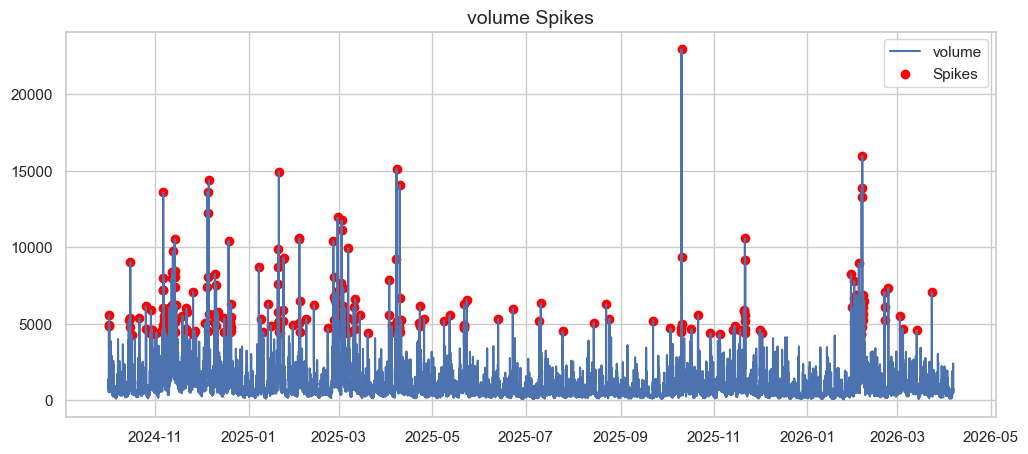

In [141]:
# Detect abnormal volume spikes (z-score)
vol_z = (df["volume"] - df["volume"].mean()) / df["volume"].std()
spikes = df[vol_z.abs() > 3]

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["volume"], label="volume")
plt.scatter(spikes.index, spikes["volume"], color="red", label="Spikes")
plt.title("volume Spikes")
plt.legend()
plt.show()

**Phan tich:** Spike volume co the lien quan den tin tuc lon, pha vo hoac day gia.

## 10. Correlation Analysis
Tinh correlation giua gia, volume, return va volatility.

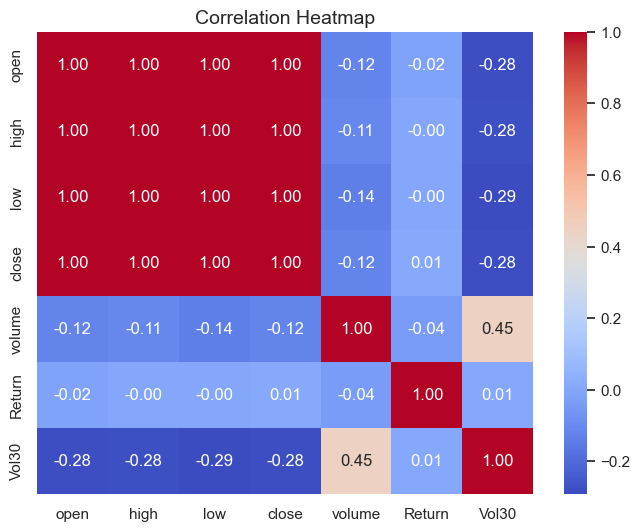

In [142]:
corr_cols = ["open", "high", "low", "close", "volume", "Return", "Vol30"]
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 11. Seasonality Analysis
Phan tich theo thang va theo ngay trong tuan.

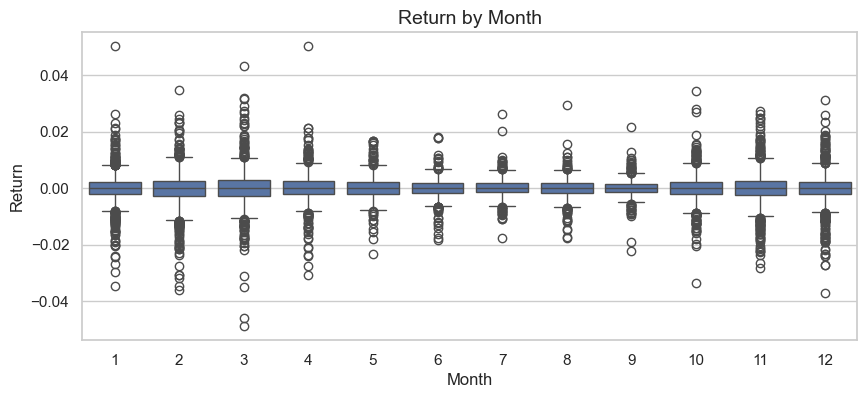

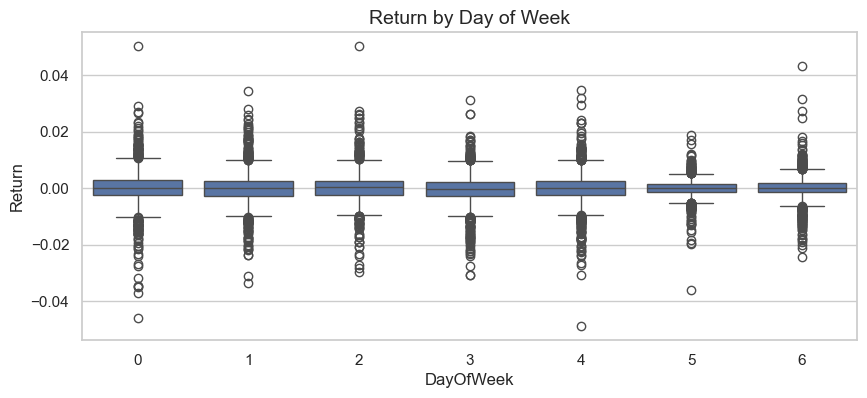

In [143]:
df["Month"] = df.index.month
df["DayOfWeek"] = df.index.dayofweek

plt.figure(figsize=(10, 4))
sns.boxplot(x="Month", y="Return", data=df)
plt.title("Return by Month")
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x="DayOfWeek", y="Return", data=df)
plt.title("Return by Day of Week")
plt.show()

**Nhan xet:** Neu co su khac biet ro rang theo thang/ngay, co the la dau hieu tinh mua vu yeu.

## 12. Stationarity Test
Su dung ADF test de kiem tra tinh stationarity.

In [144]:
adf_result = adfuller(df["close"].dropna())
pd.Series(adf_result[0:4], index=["ADF Statistic", "p-value", "Used Lags", "N Obs"])

ADF Statistic       -1.775834
p-value              0.392524
Used Lags           22.000000
N Obs            13240.000000
dtype: float64

**Giai thich:** p-value < 0.05 thi chuoi co xu huong stationarity, neu khong can differencing.

## 13. Autocorrelation Analysis
Phan tich ACF/PACF de xem do phu thuoc theo lag.

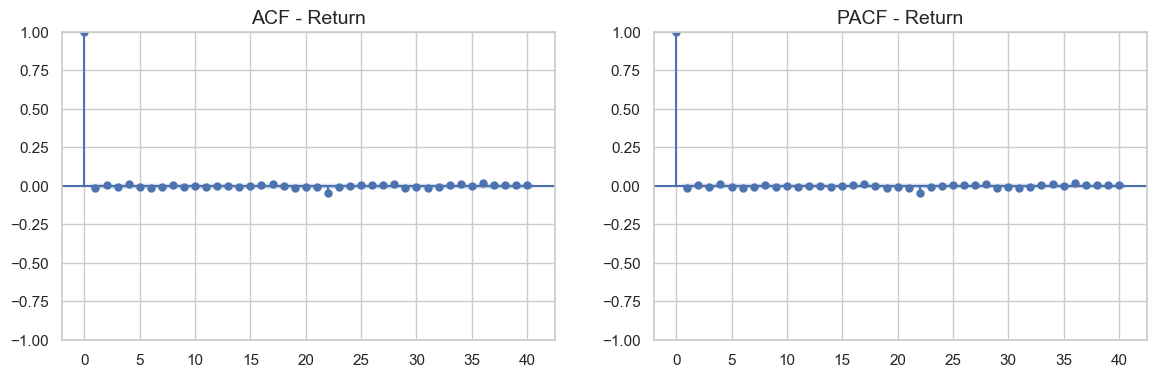

In [145]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df["Return"].dropna(), ax=ax[0], lags=40)
plot_pacf(df["Return"].dropna(), ax=ax[1], lags=40, method="ywm")
ax[0].set_title("ACF - Return")
ax[1].set_title("PACF - Return")
plt.show()

**Phan tich:** Neu cac lag giam cham, chuoi co memory dai; neu giam nhanh thi memory ngan.

## 14. Outlier Detection
Su dung IQR va Z-score de phat hien outlier.

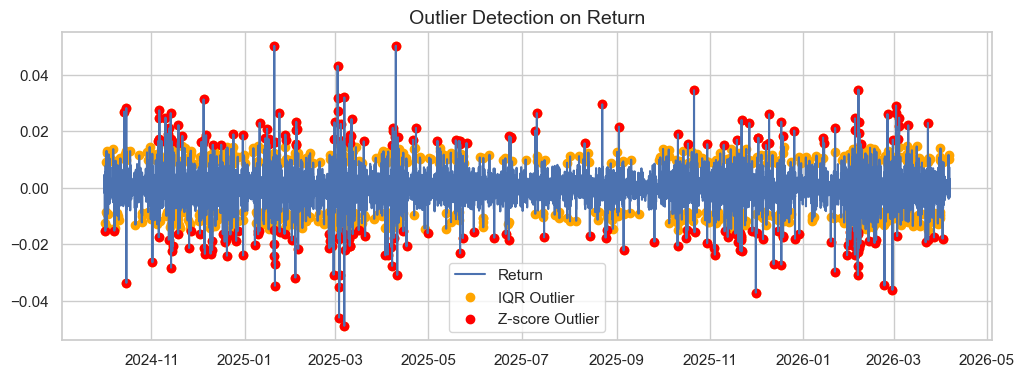

In [146]:
# IQR method
q1 = df["Return"].quantile(0.25)
q3 = df["Return"].quantile(0.75)
iqr = q3 - q1
out_iqr = df[(df["Return"] < q1 - 1.5 * iqr) | (df["Return"] > q3 + 1.5 * iqr)]

# Z-score method
z = (df["Return"] - df["Return"].mean()) / df["Return"].std()
out_z = df[z.abs() > 3]

plt.figure(figsize=(12, 4))
plt.plot(df.index, df["Return"], label="Return")
plt.scatter(out_iqr.index, out_iqr["Return"], color="orange", label="IQR Outlier")
plt.scatter(out_z.index, out_z["Return"], color="red", label="Z-score Outlier")
plt.title("Outlier Detection on Return")
plt.legend()
plt.show()

## 15. Market Regime Detection
Phan loai che do thi truong bang KMeans dua tren return, volatility va volume.

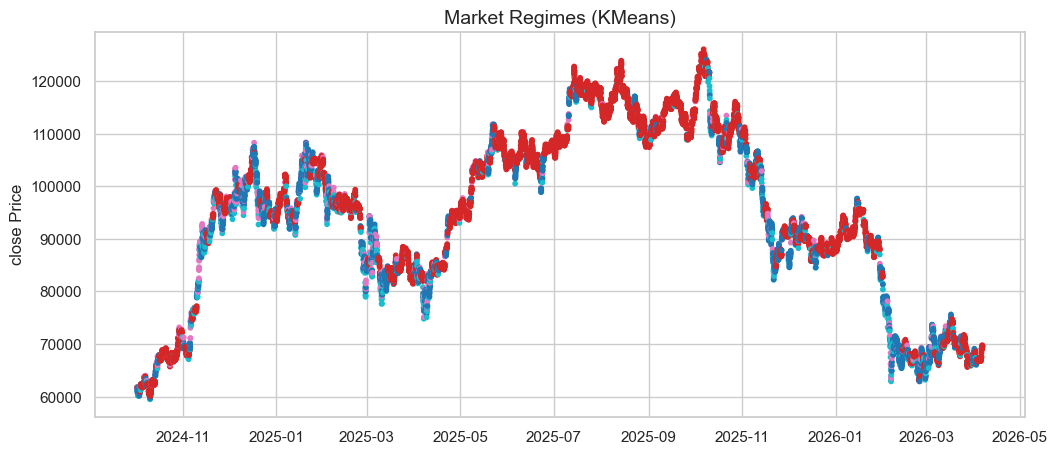

In [147]:
features = df[["Return", "Vol30", "volume"]].dropna()
scaler = StandardScaler()
X = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
features["Regime"] = kmeans.fit_predict(X)

plt.figure(figsize=(12, 5))
plt.scatter(features.index, df.loc[features.index, "close"], c=features["Regime"], cmap="tab10", s=10)
plt.title("Market Regimes (KMeans)")
plt.ylabel("close Price")
plt.show()

**Nhan xet:** Cac che do co the tuong ung bullish, bearish, stable, panic (xac nhan bang thong ke cua return/volatility).

## 16. Time Series Decomposition
Tach trend, seasonality va residual.

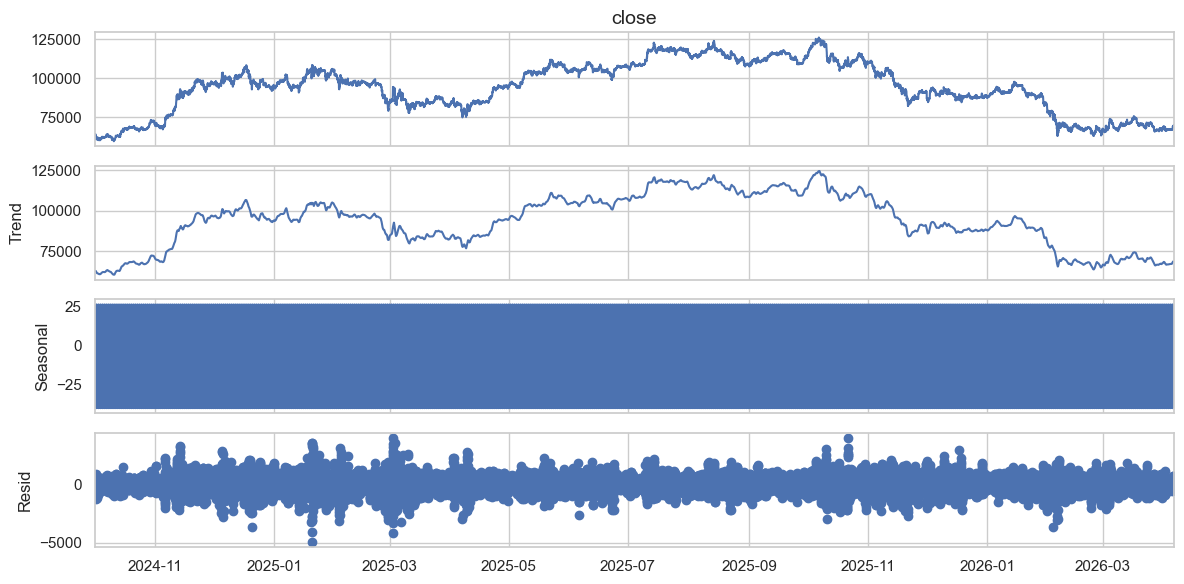

In [148]:
# Seasonal decomposition (assume daily or hourly, adjust period if needed)
decomp = seasonal_decompose(df["close"].dropna(), model="additive", period=24)
decomp.plot()
plt.show()

## 17. Insight & Conclusion
### Tong ket nghien cuu
- Thi truong BTC co xu huong khong stationarity, can differencing truoc khi modeling.
- Volatility cao va co nhieu dot spike, can quan tam risk management.
- Cac che do thi truong cho thay tinh phan giai (regime) ro rang: bullish/bearish/panic.
- Tinh mua vu yeu nhung co the ton tai theo thang/ngay.

### Trading insight
- Cac dot volatility cao thuong trung voi crash; co the dung stop-loss adaptively.
- Moving average crossover co the phu hop lam feature cho machine learning.

### Feature engineering goi y
- Lagged returns (t-1, t-2, t-7)
- Rolling volatility va rolling volume
- RSI, MACD, Bollinger Bands
- Regime label tu clustering
- Calendar features (month, dayofweek, hour)